# Checkpoint 1 
## (Do not remove any comments that start with"# @@@".) 

Reminder: 

- You are being evaluated for completion and effort in this checkpoint. 
- Avoid manual labor / hard coding as much as possible, everything we've taught you so far are meant to simplify and automate your process.
- Please do not remove any comment that starts with: "# @@@". 

We will be working with the same `states_edu.csv` that you should already be familiar with from the tutorial.

We investigated Grade 8 reading score in the tutorial. For this checkpoint, you are asked to investigate another test. Here's an overview:

* Choose a specific response variable to focus on
>Grade 4 Math, Grade 4 Reading, Grade 8 Math
* Pick or create features to use
>Will all the features be useful in predicting test score? Are some more important than others? Should you standardize, bin, or scale the data?
* Explore the data as it relates to that test
>Create at least 2 visualizations (graphs), each with a caption describing the graph and what it tells us about the data
* Create training and testing data
>Do you want to train on all the data? Only data from the last 10 years? Only Michigan data?
* Train a ML model to predict outcome 
>Define what you want to predict, and pick a model in sklearn to use (see sklearn <a href="https://scikit-learn.org/stable/modules/linear_model.html">regressors</a>).


Include comments throughout your code! Every cleanup and preprocessing task should be documented.


<h2> Data Cleanup </h2>

Import `numpy`, `pandas`, and `matplotlib`.

(Feel free to import other libraries!)

In [3]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Load in the "states_edu.csv" dataset and take a look at the head of the data

In [5]:
df = pd.read_csv("../data/states_edu.csv")
df.head()

,PRIMARY_KEY,STATE,YEAR,ENROLL,TOTAL_REVENUE,FEDERAL_REVENUE,STATE_REVENUE,LOCAL_REVENUE,TOTAL_EXPENDITURE,INSTRUCTION_EXPENDITURE,...,GRADES_4_G,GRADES_8_G,GRADES_12_G,GRADES_1_8_G,GRADES_9_12_G,GRADES_ALL_G,AVG_MATH_4_SCORE,AVG_MATH_8_SCORE,AVG_READING_4_SCORE,AVG_READING_8_SCORE
0,1992_ALABAMA,ALABAMA,1992,NaN,2678885.0,304177.0,1659028.0,715680.0,2653798.0,1481703.0,...,57948.0,58025.0,41167.0,NaN,NaN,731634.0,208.0,252.0,207.0,NaN
1,1992_ALASKA,ALASKA,1992,NaN,1049591.0,106780.0,720711.0,222100.0,972488.0,498362.0,...,9748.0,8789.0,6714.0,NaN,NaN,122487.0,NaN,NaN,NaN,NaN
2,1992_ARIZONA,ARIZONA,1992,NaN,3258079.0,297888.0,1369815.0,1590376.0,3401580.0,1435908.0,...,55433.0,49081.0,37410.0,NaN,NaN,673477.0,215.0,265.0,209.0,NaN
3,1992_ARKANSAS,ARKANSAS,1992,NaN,1711959.0,178571.0,958785.0,574603.0,1743022.0,964323.0,...,34632.0,36011.0,27651.0,NaN,NaN,441490.0,210.0,256.0,211.0,NaN
4,1992_CALIFORNIA,CALIFORNIA,1992,NaN,26260025.0,2072470.0,16546514.0,7641041.0,27138832.0,14358922.0,...,418418.0,363296.0,270675.0,NaN,NaN,5254844.0,208.0,261.0,202.0,NaN


You should always familiarize yourself with what each column in the dataframe represents. Read about the states_edu dataset here: https://www.kaggle.com/noriuk/us-education-datasets-unification-project

Use this space to rename columns, deal with missing data, etc. _(optional)_

In [6]:
df.isnull().sum()

PRIMARY_KEY                        0
STATE                              0
YEAR                               0
ENROLL                           491
TOTAL_REVENUE                    440
FEDERAL_REVENUE                  440
STATE_REVENUE                    440
LOCAL_REVENUE                    440
TOTAL_EXPENDITURE                440
INSTRUCTION_EXPENDITURE          440
SUPPORT_SERVICES_EXPENDITURE     440
OTHER_EXPENDITURE                491
CAPITAL_OUTLAY_EXPENDITURE       440
GRADES_PK_G                      173
GRADES_KG_G                       83
GRADES_4_G                        83
GRADES_8_G                        83
GRADES_12_G                       83
GRADES_1_8_G                     695
GRADES_9_12_G                    644
GRADES_ALL_G                      83
AVG_MATH_4_SCORE                1150
AVG_MATH_8_SCORE                1113
AVG_READING_4_SCORE             1065
AVG_READING_8_SCORE             1153
dtype: int64

<h2>Exploratory Data Analysis (EDA) </h2>

Chosen one of Grade 4 Reading, Grade 4 Math, or Grade 8 Math to focus on: Grade 4 Reading

How many years of data are logged in our dataset? 

In [7]:
# @@@ 1
df["YEAR"].nunique()

33

Let's compare Michigan to Ohio. Which state has the higher average across all years in the test you chose?

In [8]:
# @@@ 2
df[df["STATE"].isin(["MICHIGAN", "OHIO"])] \
    .groupby("STATE")["AVG_READING_4_SCORE"].mean()


# Ohio has higher average. 

STATE
MICHIGAN    217.833333
OHIO        223.181818
Name: AVG_READING_4_SCORE, dtype: float64

Find the average for your chosen test across all states in 2019

In [9]:
# @@@ 3
df[df["YEAR"] == 2019]["AVG_READING_4_SCORE"].mean()

219.79245283018867

For each state, find a maximum value for your chosen test score

In [10]:
# @@@ 4
df.groupby("STATE")["AVG_READING_4_SCORE"].max().sort_values(ascending=True)

STATE
NEW_MEXICO              212.0
ALASKA                  214.0
DISTRICT_OF_COLUMBIA    214.0
ARIZONA                 216.0
CALIFORNIA              216.0
LOUISIANA               216.0
HAWAII                  218.0
NEVADA                  218.0
SOUTH_CAROLINA          218.0
MISSISSIPPI             219.0
WEST_VIRGINIA           219.0
ARKANSAS                219.0
TENNESSEE               220.0
MICHIGAN                220.0
OREGON                  220.0
TEXAS                   220.0
ALABAMA                 220.0
GEORGIA                 222.0
ILLINOIS                222.0
OKLAHOMA                222.0
IDAHO                   223.0
NATIONAL                223.0
SOUTH_DAKOTA            223.0
NEW_YORK                224.0
WISCONSIN               224.0
MISSOURI                224.0
KANSAS                  225.0
IOWA                    225.0
RHODE_ISLAND            225.0
WASHINGTON              226.0
UTAH                    226.0
DELAWARE                226.0
NORTH_CAROLINA          226.0
NORT

*Refer to the `Grouping and Aggregating` section in Tutorial 0 if you are stuck.

<h2> Feature Engineering </h2>

After exploring the data, you can choose to modify features that you would use to predict the performance of the students on your chosen response variable. 

You can also create your own features. For example, perhaps you figured that maybe a state's expenditure per student may affect their overall academic performance so you create a expenditure_per_student feature.

Use this space to modify or create features.

In [11]:
# @@@ 5

df["EXPENDITURE_PER_STUDENT"] = (
    df["TOTAL_EXPENDITURE"] / df["ENROLL"]
)
# Total spending alone does not account for differences in state enrollment 
# and expenditure per student may provide a more meaningful measure of the resources available to each student 
# and help explain differences in academic performance. 

df["INSTRUCTION_SPENDING_RATIO"] = (
    df["INSTRUCTION_EXPENDITURE"] / df["TOTAL_EXPENDITURE"]
)

# tells us what proportion of a state's total spending goes toward instruction.

df["FEDERAL_REVENUE_RATIO"] = (
    df["FEDERAL_REVENUE"] / df["TOTAL_REVENUE"]
)

# measures how much of a state's total education revenue comes from federal funding.


Feature engineering justification: **<BRIEFLY DESCRIBE WHY YOU MADE THE CHANGES THAT YOU DID\>**

<h2>Visualization</h2>

Investigate the relationship between your chosen response variable and at least two predictors using visualizations. Write down your observations.

**Visualization 1**

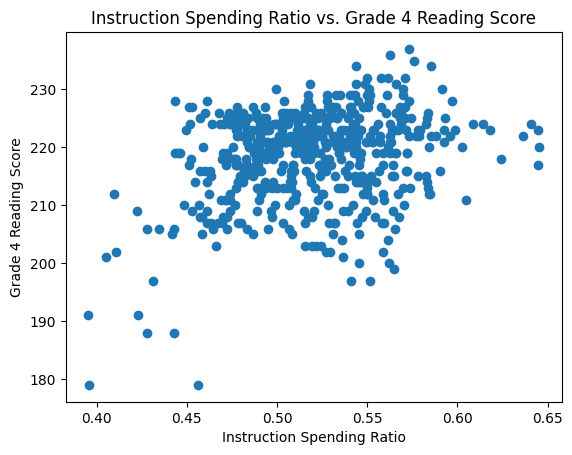

In [12]:
# @@@ 6
plt.scatter(df["INSTRUCTION_SPENDING_RATIO"], df["AVG_READING_4_SCORE"])
plt.xlabel("Instruction Spending Ratio")
plt.ylabel("Grade 4 Reading Score")
plt.title("Instruction Spending Ratio vs. Grade 4 Reading Score")
plt.show()

**<Relationship between instruction spending per student and Grade 4 reading scores across states and years.>**

#### They are highely likely to have weak positive relationship, meaning that reading scores tend to be slightly higher as the instruction spending ratio increases. However, the points are widely scattered, so the relationship is not very strong.

**Visualization 2**

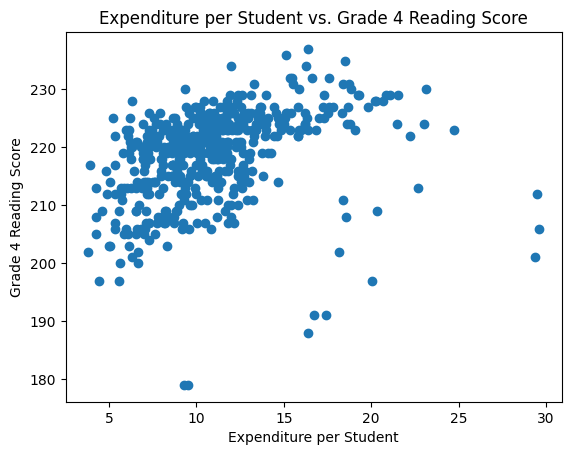

In [13]:
# @@@ 7
plt.scatter(df["EXPENDITURE_PER_STUDENT"], df["AVG_READING_4_SCORE"])
plt.xlabel("Expenditure per Student")
plt.ylabel("Grade 4 Reading Score")
plt.title("Expenditure per Student vs. Grade 4 Reading Score")
plt.show()

**<Relationship between expenditure per student and Grade 4 reading scores across states and years.>**

#### They are highley likely to have positive relationship, with reading scores generally increasing as expenditure per student increases. However, there are several outliers, particularly at higher expenditure levels, where reading scores vary considerably

<h2> Data Creation </h2>

_Use this space to create train/test data_

In [14]:
%pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [15]:
from sklearn.model_selection import train_test_split

In [31]:
# @@@ 8
df_model = df.dropna(
    subset=[
        "EXPENDITURE_PER_STUDENT",
        "INSTRUCTION_SPENDING_RATIO",
        "AVG_READING_4_SCORE"
    ]
)

X = X = df_model[[
    "EXPENDITURE_PER_STUDENT",
    "INSTRUCTION_SPENDING_RATIO"
]]
y = df_model["AVG_READING_4_SCORE"]

In [32]:
# @@@ 9 

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

<h2> Prediction </h2>

ML Models [Resource](https://medium.com/@vijaya.beeravalli/comparison-of-machine-learning-classification-models-for-credit-card-default-data-c3cf805c9a5a)

In [33]:
# @@@ 10
# import your sklearn class here
from sklearn.linear_model import LinearRegression

In [34]:
# @@@ 11
# create your model here
model = LinearRegression()

In [35]:
model.fit(X_train, y_train)

LinearRegression()

In [36]:
y_pred = model.predict(X_test)

## Evaluation

Choose some metrics to evaluate the performance of your model, some of them are mentioned in the tutorial.

In [39]:
# @@@ 12
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("R^2:", r2)

MAE: 5.432905250924386
MSE: 44.51939351594589
R^2: 0.2731183888366734


We have copied over the graphs that visualize the model's performance on the training and testing set. 

Change `col_name` and modify the call to `plt.ylabel()` to isolate how a single predictor affects the model.

Text(0.5, 1.0, 'Model Behavior On Training Set')

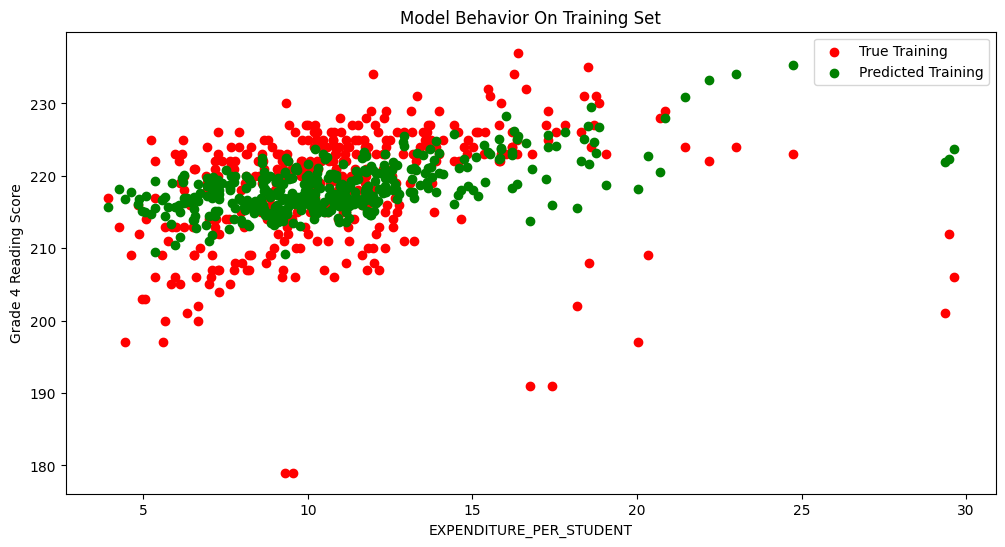

In [44]:
# @@@ 13

col_name = 'EXPENDITURE_PER_STUDENT'


f = plt.figure(figsize=(12,6))
plt.scatter(X_train[col_name], y_train, color = "red")
plt.scatter(X_train[col_name], model.predict(X_train), color = "green")

plt.legend(['True Training','Predicted Training'])
plt.xlabel(col_name)
plt.ylabel('Grade 4 Reading Score')
plt.title("Model Behavior On Training Set")

Text(0.5, 1.0, 'Model Behavior on Testing Set')

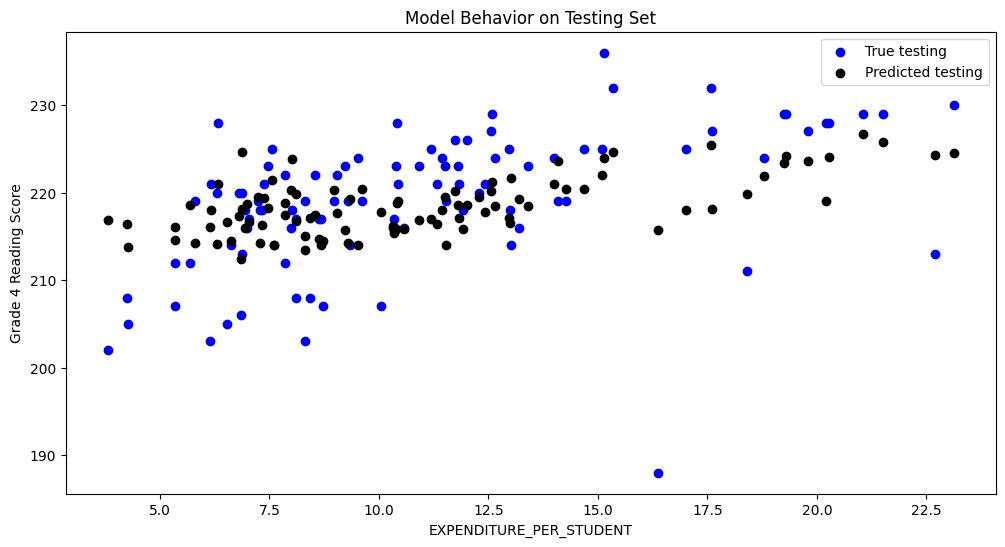

In [41]:
# @@@ 14


col_name = 'EXPENDITURE_PER_STUDENT'


f = plt.figure(figsize=(12,6))
plt.scatter(X_test[col_name], y_test, color = "blue")
plt.scatter(X_test[col_name], model.predict(X_test), color = "black")

plt.legend(['True testing','Predicted testing'])
plt.xlabel(col_name)
plt.ylabel('Grade 4 Reading Score')
plt.title("Model Behavior on Testing Set")